# Q4. Global Thresholding using Otsu’s Method

**Objective:** Implement Otsu’s method from scratch, inspect its variance criterion, and apply the automatically selected threshold to a bimodal grayscale image.

We use the same clean, shaded synthetic mug as Q3. Its dark background and bright object form two clearly separated intensity populations. No random texture or third bright region is introduced. Only NumPy and Matplotlib are required; run all cells in order.

Otsu selects a threshold that maximizes the **between-class variance**:

$$\sigma_B^2(T)=\omega_0(T)\omega_1(T)[\mu_0(T)-\mu_1(T)]^2.$$

Here $\omega_0,\omega_1$ are class probabilities and $\mu_0,\mu_1$ are class means. Because total variance is fixed and equals within-class variance plus between-class variance, maximizing this expression is equivalent to minimizing within-class variance.


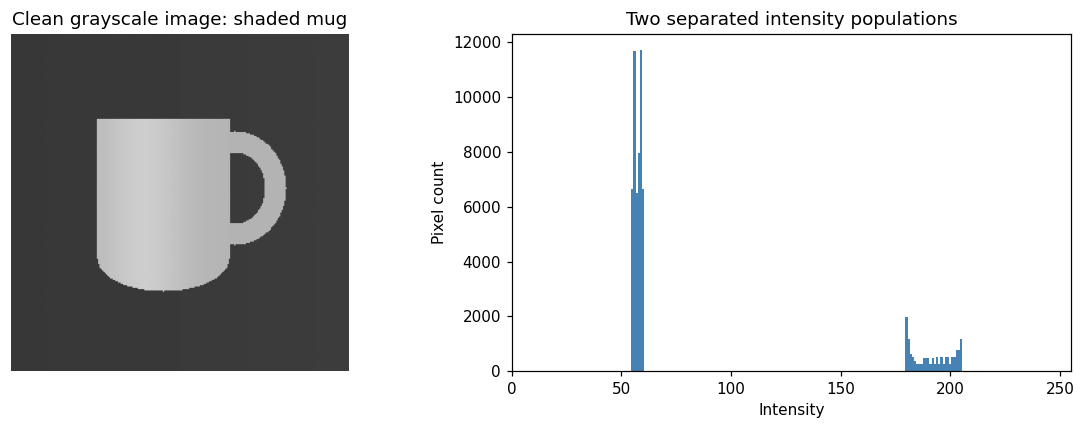

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A deterministic illustration: no random noise in the clean image.
# Smooth shading is image structure, not noise.
H, W = 256, 256
yy, xx = np.mgrid[:H, :W]
body = (xx >= 65) & (xx <= 165) & (yy >= 65) & (yy <= 170)
bottom = ((xx - 115) / 50) ** 2 + ((yy - 170) / 25) ** 2 <= 1
bottom &= yy >= 170
outer_handle = ((xx - 169) / 39) ** 2 + ((yy - 117) / 43) ** 2 <= 1
inner_handle = ((xx - 169) / 23) ** 2 + ((yy - 117) / 27) ** 2 < 1
handle = outer_handle & ~inner_handle & (xx >= 157)
foreground_mask = body | bottom | handle

background = 55 + 5 * xx / (W - 1)
object_shading = 180 + 25 * np.exp(-(((xx - 100) / 32) ** 2))
clean = np.rint(np.where(foreground_mask, object_shading, background)).astype(np.uint8)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

image = clean.copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Clean grayscale image: shaded mug")
axes[0].axis("off")
axes[1].hist(image.ravel(), bins=np.arange(257) - 0.5, color="steelblue")
axes[1].set(
    title="Two separated intensity populations",
    xlabel="Intensity",
    ylabel="Pixel count",
    xlim=(0, 255),
)
plt.tight_layout()
plt.show()


## 1. Compute the normalized histogram

Let $n_i$ be the number of pixels having intensity $i$, and $N$ be the total number of pixels.

The normalized histogram is

$$
p(i)=\frac{n_i}{N},
$$

which behaves as a probability distribution over the 256 possible gray levels.

Sum of normalized histogram probabilities = 1.0


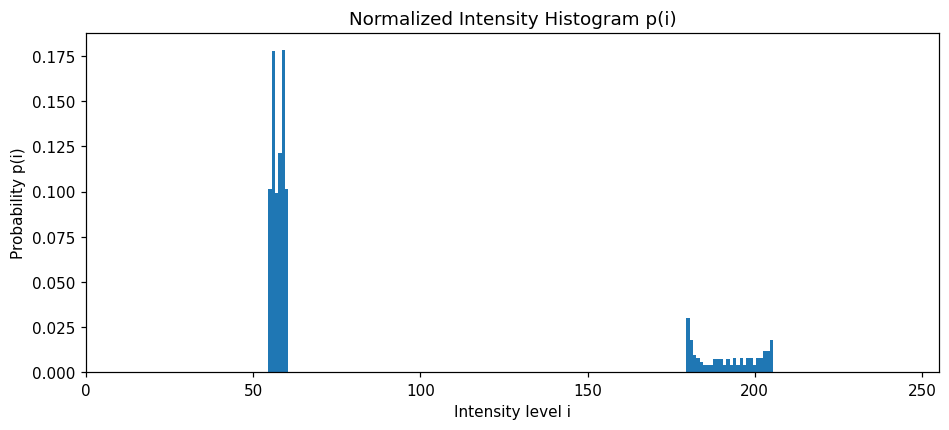

In [2]:
# Histogram counts for intensities 0...255
hist = np.bincount(image.ravel(), minlength=256).astype(np.float64)

# Normalize to obtain probabilities
prob = hist / hist.sum()

print("Sum of normalized histogram probabilities =", prob.sum())

plt.figure(figsize=(10, 4))
plt.bar(np.arange(256), prob, width=1.0)
plt.title("Normalized Intensity Histogram p(i)")
plt.xlabel("Intensity level i")
plt.ylabel("Probability p(i)")
plt.xlim(0, 255)
plt.show()


## 2. Calculate the between-class variance for every threshold

For each possible threshold $T$:

- Class $C_0=\{0,\dots,T\}$
- Class $C_1=\{T+1,\dots,255\}$

Their probabilities are

$$
\omega_0(T)=\sum_{i=0}^{T}p(i), \qquad
\omega_1(T)=1-\omega_0(T).
$$

Their means are

$$
\mu_0(T)=\frac{\sum_{i=0}^{T} i\,p(i)}{\omega_0(T)},
\qquad
\mu_1(T)=\frac{\sum_{i=T+1}^{255} i\,p(i)}{\omega_1(T)}.
$$

Then

$$
\sigma_B^2(T)=\omega_0(T)\omega_1(T)[\mu_0(T)-\mu_1(T)]^2.
$$

The implementation below is written explicitly rather than calling a library Otsu routine.

In [3]:
def otsu_from_scratch(gray_image):
    if gray_image.ndim != 2 or gray_image.size == 0 or gray_image.dtype != np.uint8:
        raise ValueError("Expected a non-empty, two-dimensional uint8 grayscale image.")
    hist = np.bincount(gray_image.ravel(), minlength=256)
    N = gray_image.size
    prob = hist.astype(np.float64) / N
    total_sum = np.dot(np.arange(256, dtype=np.float64), hist)
    between_var = np.zeros(256, dtype=np.float64)
    valid = np.zeros(256, dtype=bool)
    count0 = 0
    sum0 = 0.0

    for T in range(256):
        count0 += int(hist[T])
        sum0 += T * int(hist[T])
        count1 = N - count0
        # Integer counts avoid rounding errors when detecting empty classes.
        if count0 == 0 or count1 == 0:
            continue
        valid[T] = True
        w0, w1 = count0 / N, count1 / N
        mu0, mu1 = sum0 / count0, (total_sum - sum0) / count1
        between_var[T] = w0 * w1 * (mu0 - mu1) ** 2

    if not valid.any():
        raise ValueError(
            "A constant image has no threshold giving two non-empty classes."
        )
    # Deterministic tie policy: select the first maximizing threshold.
    optimal_T = int(np.argmax(between_var))
    return optimal_T, between_var, prob


T_opt, sigma_B2, prob = otsu_from_scratch(image)
maximizers = np.flatnonzero(sigma_B2 == sigma_B2[T_opt])
print(f"Optimal threshold (first maximum): T = {T_opt}")
print(f"Maximum between-class variance: {sigma_B2[T_opt]:.4f}")
print(f"Equally optimal thresholds: {maximizers[0]} through {maximizers[-1]}")


Optimal threshold (first maximum): T = 60
Maximum between-class variance: 3088.6611
Equally optimal thresholds: 60 through 179


## 3. Plot between-class variance versus threshold

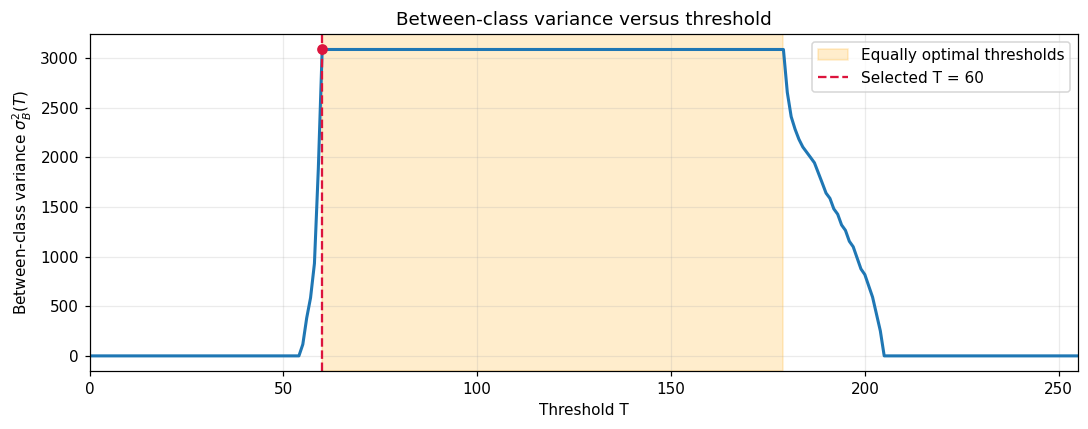

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(np.arange(256), sigma_B2, linewidth=2)
plt.axvspan(
    maximizers[0],
    maximizers[-1],
    color="orange",
    alpha=0.2,
    label="Equally optimal thresholds",
)
plt.axvline(T_opt, color="crimson", linestyle="--", label=f"Selected T = {T_opt}")
plt.scatter([T_opt], [sigma_B2[T_opt]], color="crimson", zorder=3)
plt.title("Between-class variance versus threshold")
plt.xlabel("Threshold T")
plt.ylabel(r"Between-class variance $\sigma_B^2(T)$")
plt.xlim(0, 255)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


The optimum is a **plateau**, not necessarily one unique threshold. Moving T through the empty intensity gap does not move any pixel between classes, so the variance and segmentation stay identical. `np.argmax` selects the first maximum, at the last occupied background intensity. A threshold near the middle of the gap produces the same mask for this image.

Thresholds with an empty class have their plotted variance set to zero and are not valid splits. In particular, T = 255 always leaves the brighter class empty. A constant image has no valid two-class split, so the function raises a clear error.


## 4. Apply the optimal threshold

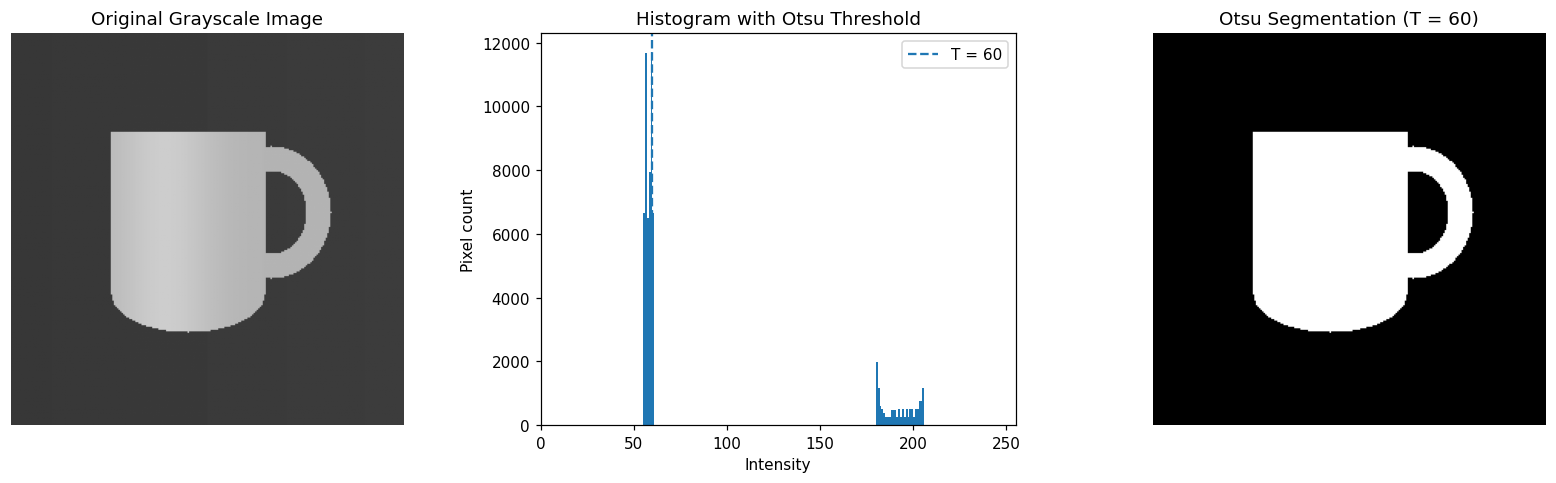

In [5]:
binary = np.where(image > T_opt, 255, 0).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].imshow(image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Grayscale Image")
axes[0].axis("off")

axes[1].hist(image.ravel(), bins=256, range=(0, 256))
axes[1].axvline(T_opt, linestyle="--", label=f"T = {T_opt}")
axes[1].set_title("Histogram with Otsu Threshold")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Pixel count")
axes[1].set_xlim(0, 255)
axes[1].legend()

axes[2].imshow(binary, cmap="gray", vmin=0, vmax=255)
axes[2].set_title(f"Otsu Segmentation (T = {T_opt})")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Optional verification of the class statistics at the selected threshold

In [6]:
prediction = binary == 255
print(f"Background fraction: {np.mean(~prediction):.4f}")
print(f"Foreground fraction: {np.mean(prediction):.4f}")
print(
    f"Pixel error against geometric ground truth: {100 * np.mean(prediction != foreground_mask):.3f}%"
)

# Verify the histogram, exact clean segmentation, and variance identity.
assert np.isclose(prob.sum(), 1)
assert np.array_equal(prediction, foreground_mask)
c0 = image[~prediction].astype(float)
c1 = image[prediction].astype(float)
within_var = (c0.size * c0.var() + c1.size * c1.var()) / image.size
assert np.isclose(image.var(), within_var + sigma_B2[T_opt])

# Independently calculate the criterion by directly splitting pixels.
direct = np.zeros(256)
for t in range(256):
    a, b = image[image <= t], image[image > t]
    if a.size and b.size:
        direct[t] = (
            (a.size / image.size) * (b.size / image.size) * (a.mean() - b.mean()) ** 2
        )
assert np.allclose(sigma_B2, direct)
try:
    otsu_from_scratch(np.full((4, 4), 90, dtype=np.uint8))
except ValueError:
    pass
else:
    raise AssertionError("Constant-image handling failed")
print(
    "Checks passed: histogram, ground truth, variance identity, all thresholds, constant image."
)


Background fraction: 0.7805
Foreground fraction: 0.2195
Pixel error against geometric ground truth: 0.000%
Checks passed: histogram, ground truth, variance identity, all thresholds, constant image.


## 5. Discussion: limitations of Otsu's method

### Unimodal histogram

Otsu's method works best when the histogram contains two reasonably separated classes. If the histogram is **unimodal**,
there is no strong valley separating foreground and background. Otsu will still return the threshold that mathematically
maximizes between-class variance, but the resulting split may not correspond to a meaningful object-background boundary.

### Significant illumination variation

A single global threshold assumes that similar objects have similar intensity throughout the whole image. Under
**non-uniform illumination**, pixels belonging to the same physical class can have very different intensities in different
parts of the image. The foreground and background distributions then broaden or overlap, and one global threshold may
segment one region correctly while failing elsewhere.

### Practical implication

For unimodal data or strong illumination gradients, alternatives such as **adaptive/local thresholding**, illumination
correction, background normalization, or more advanced segmentation methods can perform better.

**Conclusion:** Otsu's method is simple, automatic, and effective for well-separated bi-modal histograms, but its performance
degrades when the two-class assumption is weak.

## Visual examples of the limitations

The first example is a single uniform surface with Gaussian noise: there is **no true object**. The second adds a strong left-to-right illumination gradient to the mug, making dark object pixels overlap bright background pixels. The same Otsu function is applied independently to each image.


Unimodal surface: 48.7% labeled foreground despite no true object.
Uneven illumination: 32.12% pixel error.


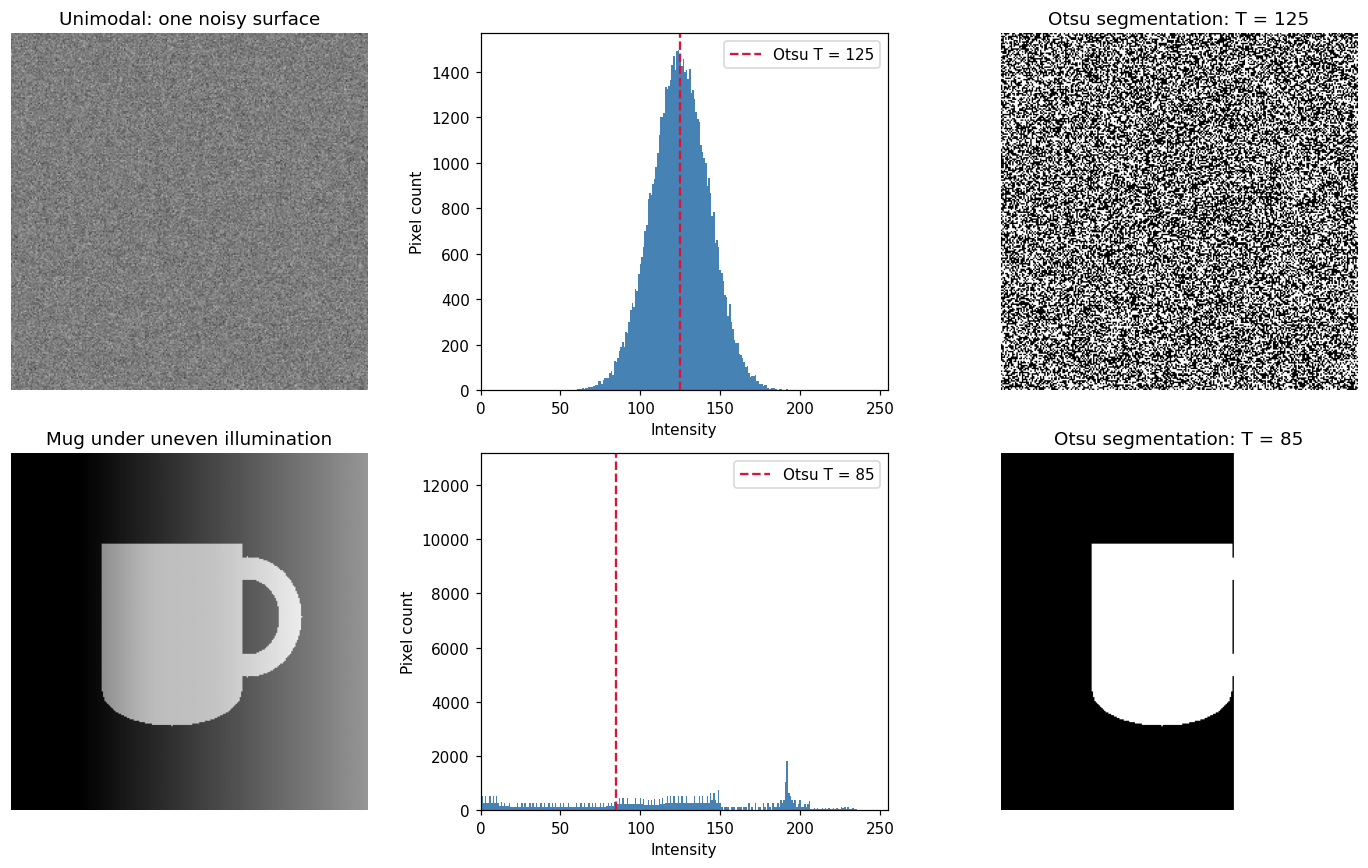

In [7]:
rng = np.random.default_rng(7)
unimodal = np.rint(np.clip(rng.normal(125, 18, (H, W)), 0, 255)).astype(np.uint8)
illumination = 180 * (xx / (W - 1) - 0.5)
uneven = np.rint(np.clip(image.astype(float) + illumination, 0, 255)).astype(np.uint8)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for row, (title, example) in enumerate(
    [
        ("Unimodal: one noisy surface", unimodal),
        ("Mug under uneven illumination", uneven),
    ]
):
    t, _, _ = otsu_from_scratch(example)
    mask = example > t
    axes[row, 0].imshow(example, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_title(title)
    axes[row, 0].axis("off")
    axes[row, 1].hist(example.ravel(), bins=np.arange(257) - 0.5, color="steelblue")
    axes[row, 1].axvline(t, color="crimson", linestyle="--", label=f"Otsu T = {t}")
    axes[row, 1].set(xlim=(0, 255), xlabel="Intensity", ylabel="Pixel count")
    axes[row, 1].legend()
    axes[row, 2].imshow(mask, cmap="gray", vmin=0, vmax=1)
    axes[row, 2].set_title(f"Otsu segmentation: T = {t}")
    axes[row, 2].axis("off")
    if row == 0:
        print(
            f"Unimodal surface: {np.mean(mask):.1%} labeled foreground despite no true object."
        )
    else:
        print(
            f"Uneven illumination: {np.mean(mask != foreground_mask):.2%} pixel error."
        )
plt.tight_layout()
plt.show()


For the unimodal surface, Otsu separates brightness fluctuations into two classes without finding a meaningful object. Under uneven illumination, it uses one threshold everywhere and confuses some background and mug pixels. Its objective depends on histogram counts, not pixel locations or object identity. Illumination correction or local thresholds can help with spatial lighting changes; unimodality may require different object cues altogether.
